We will use data files from this project:
https://engineering.case.edu/bearingdatacenter

Data was collected at 12,000 samples/second and at 48,000 samples/second for drive end bearing experiments.  All fan end bearing data was collected at 12,000 samples/second. 

Definitions of terms:
- **DE** - drive end accelerometer data
- **FE** - fan end accelerometer data
- **BA** - base accelerometer data
- **RPM** - rpm during testing


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from IPython.display import display, Markdown
import sys
from pathlib import Path
# shim for working with local copy
if str(Path.cwd().parent.parent.name) == 'scaleo':
    parent_dir = str(Path.cwd().parent.parent.parent)
    if parent_dir not in sys.path:
        sys.path.append(parent_dir)
from scaleo import CWT

In [2]:
import scipy.io as sio
import requests
import io


def get_mat(url:str):
    # Fetch the file from the URL
    response = requests.get(url)
    response.raise_for_status()  # Check if the request was successful
    
    # Load the file into SciPy
    file_stream = io.BytesIO(response.content)
    mat_data = sio.loadmat(file_stream)
    
    print(mat_data.keys())
    # 2. Extract your specific variable array by its MATLAB workspace name
    # (Tip: Check mat_data.keys() to see available variable names)
    # mat_array = mat_data['X097_DE_time']
    
    data_keys = [key for key in mat_data.keys() if not key.startswith("__")]
    time_key = [k for k in mat_data.keys() if 'time' in k][0]
    time_len = len(mat_data[time_key])
    df = pd.DataFrame({key: mat_data[key].flatten() for key in data_keys if len(mat_data[key])  == time_len})
    return df

# Normal Baseline Data. RPM = 1797
good_url = "https://engineering.case.edu/sites/default/files/97.mat"
# 12k Drive End Bearing Fault Data (Ball). RPM = 1797
bad_url = "https://engineering.case.edu/sites/default/files/118.mat"

df_good = get_mat(good_url)
df_bad = get_mat(bad_url)

dict_keys(['__header__', '__version__', '__globals__', 'X097_DE_time', 'X097_FE_time', 'X097RPM'])
dict_keys(['__header__', '__version__', '__globals__', 'X118_DE_time', 'X118_FE_time', 'X118_BA_time', 'X118RPM'])


In [3]:
wavelet_name = 'fbsp2-1.5-1.0'
periods=np.linspace(5,950,200)
fs = 12000.  # 12 kHZ sample rate
xlabel = f"Time. Sample rate {fs} HZ"

D:\projects\jupyter\workdir\MIA\scaleo\__init__.py:182: RuntimeWarning: Reduced image to max allowed resolution 4000x4000 pixels
  warnings.warn(f"Reduced image to max allowed resolution {CWT.IMG_MAX_ROWS * 2}x{CWT.IMG_MAX_COLS * 2} pixels", RuntimeWarning)


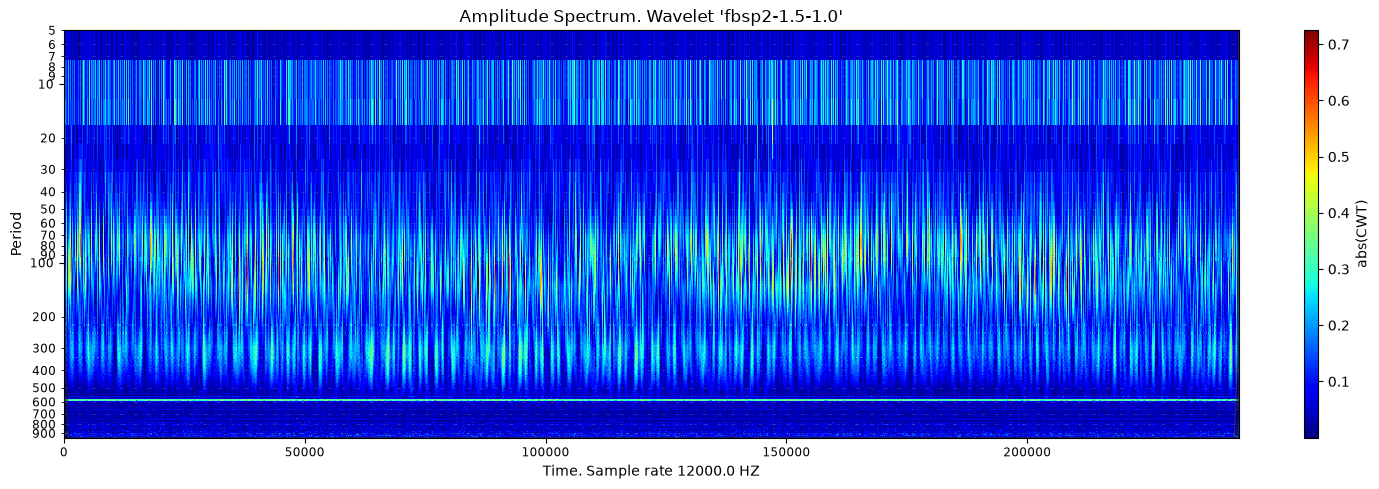

In [4]:
signal = df_good['X097_DE_time']
time = df_good.index
cwt = CWT(signal, 1, time, wavelet_name, xlabel=xlabel)
_ = cwt.cwt(periods=periods, method='fft')
cwt.scalogram(cmap='jet', figsize=(14,5), logscale=True)

The large time period and data density make it difficult to see the details. Let's consider only the first 10k samples.

We will also continue to specify that when calling CWT, sample rate is equal to 1, which results in the display of pseudo-values of periods along the Y-axis.

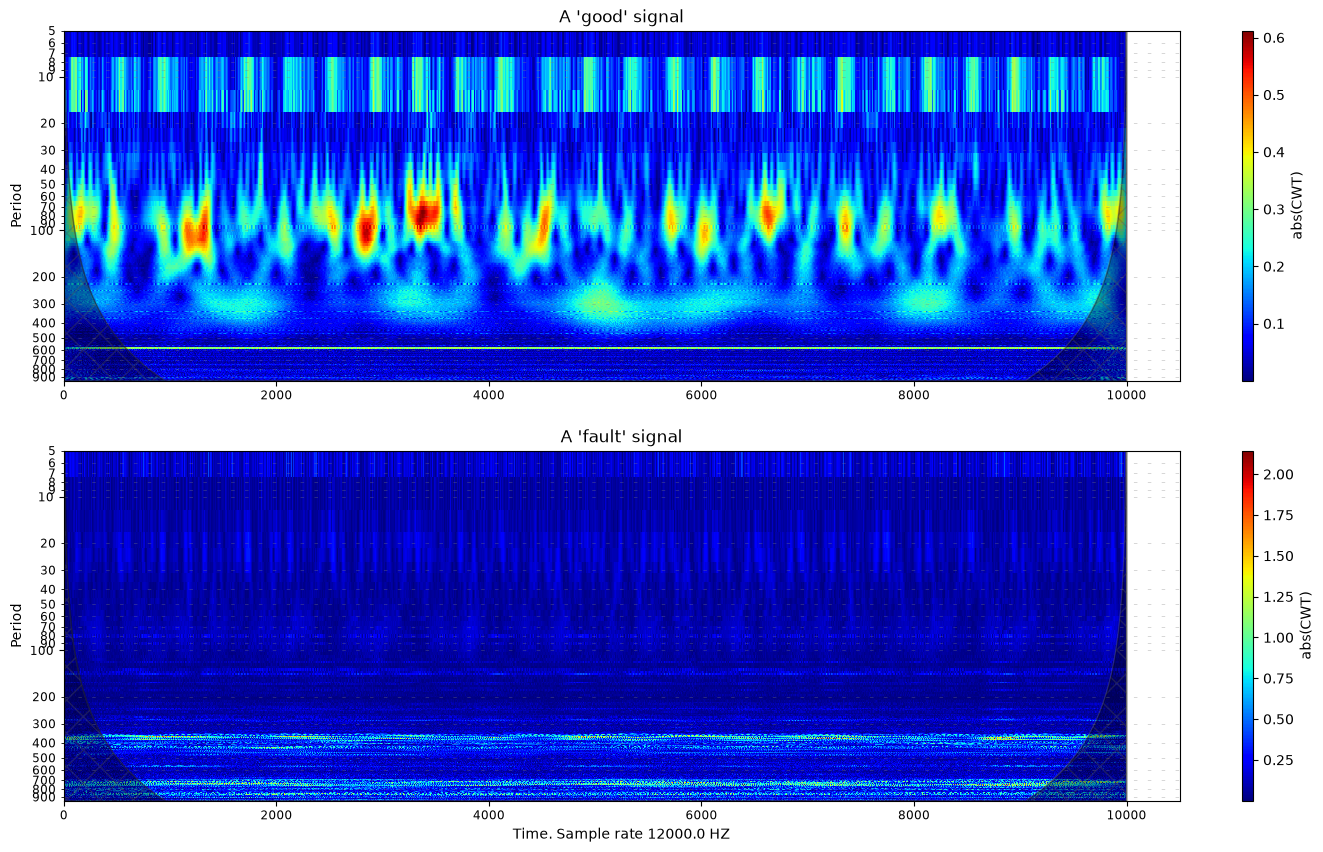

In [5]:
def scalo(cwt1, cwt2, title1:str=None, title2:str=None, spectrum='amp'):
    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(16,10))
    cwt1.scalogram(cmap='jet', ax=ax1, logscale=True, spectrum=spectrum)
    ax1.set_title(title1)
    ax1.set_xlabel(None)
    cwt2.scalogram(cmap='jet', ax=ax2, logscale=True, spectrum=spectrum)
    ax2.set_title(title2)
    plt.show()

signal = df_good['X097_DE_time'][:10000]
time = df_good.index[:10000]
cwt_good = CWT(signal, 1, time, wavelet_name, xlabel=xlabel)
signal = df_bad['X118_DE_time'][:10000]
time = df_bad.index[:10000]
cwt_bad  = CWT(signal, 1, time, wavelet_name, xlabel=xlabel)
_ = cwt_good.cwt(periods=periods, method='fft')
_ = cwt_bad.cwt(periods=periods, method='fft')
scalo(cwt_good, cwt_bad, "A 'good' signal", "A 'fault' signal")

Please note that the min-max values on the colorbar are different, which results in different brightness of the same areas on the two scalograms.

First image shows stable vibration approx. 580 'pseudoperiods'. This is probably the natural resonance frequency of the device under these conditions, which does not yet have any damage.
Second image shows new frequency bands with much more higher amplitudes than found on first image. It is likely that the destruction of the rolling surface leads to the appearance of new vibrations.

Let's take the detected periods with high signal power and find identical ones in both CWT's. Then we will find new vibrations that appeared on measured device with faults.

Match: good[0]=14.4975 and fault[0]=19.2462 (Diff: 4.75)
Match: good[1]=85.7286 and fault[1]=80.9799 (Diff: 4.75)
Match: good[2]=247.1859 and fault[3]=237.6884 (Diff: 9.50)
Match: good[3]=294.6734 and fault[4]=285.1759 (Diff: 9.50)
Match: good[4]=375.402 and fault[5]=361.1558 (Diff: 14.25)
Match: good[5]=470.3769 and fault[7]=475.1256 (Diff: 4.75)
Match: good[7]=579.598 and fault[8]=570.1005 (Diff: 9.50)
Match: good[8]=660.3266 and fault[10]=674.5729 (Diff: 14.25)
Match: good[9]=745.804 and fault[11]=726.809 (Diff: 18.99)
Match: good[10]=817.0352 and fault[12]=812.2864 (Diff: 4.75)
Match: good[11]=897.7638 and fault[14]=916.7588 (Diff: 18.99)


---

Periods from 'fault' CWT that did not appears in 'good' CWT:

**142.7136**, **427.6382**, **627.0854**, **864.5226**

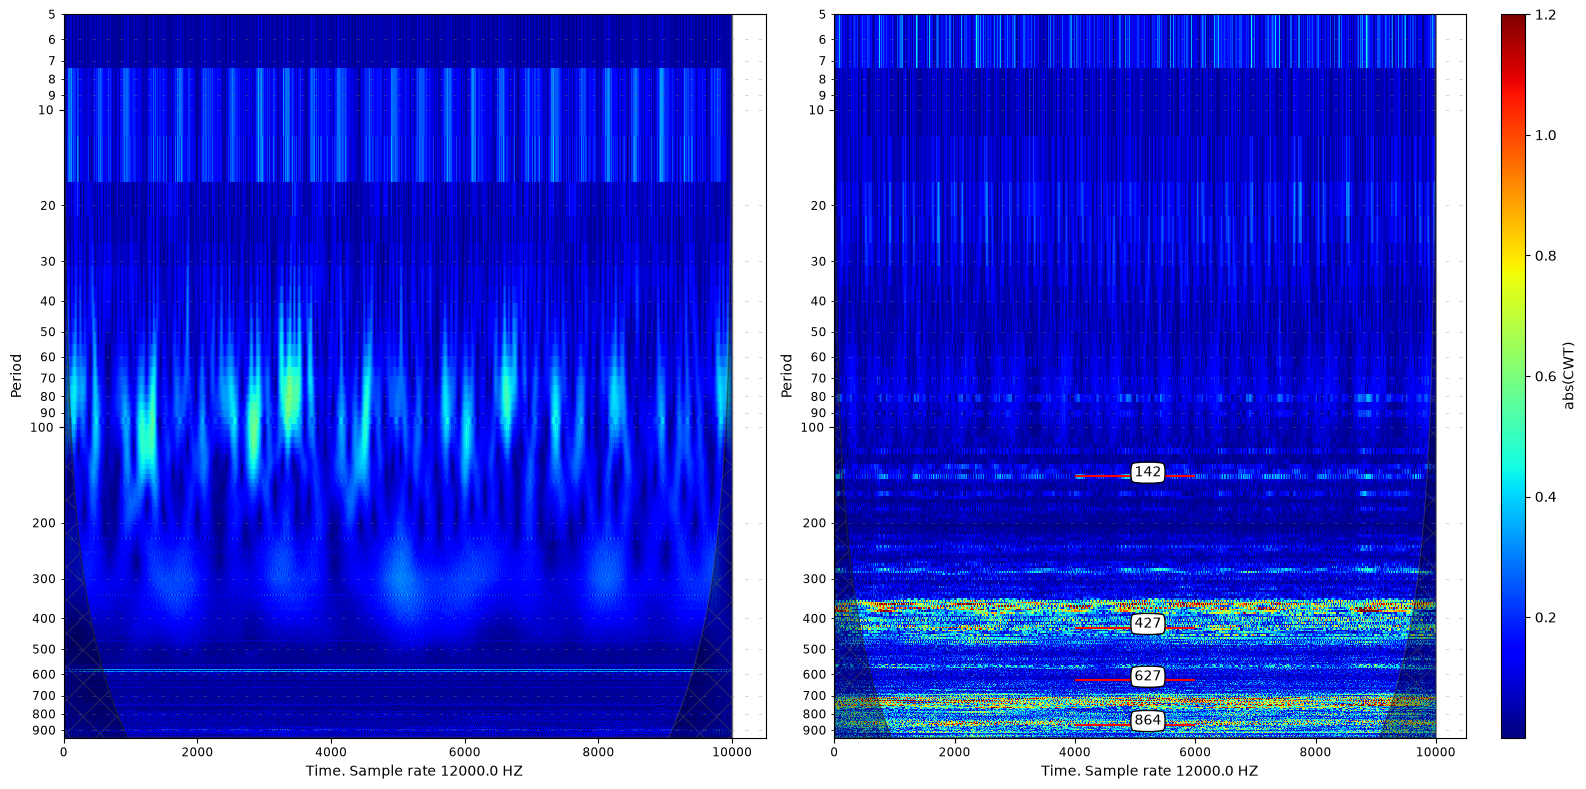

In [11]:
a = np.array(cwt_good.detect_power_peaks())
b = np.array(cwt_bad.detect_power_peaks())
threshold = 20

diffs = np.abs(a[:, None] - b)
matches = diffs <= threshold
non_match = diffs > threshold
idx_a, idx_b = np.where(matches)
for i, j in zip(idx_a, idx_b):
    print(f"Match: good[{i}]={round(a[i],4)} and fault[{j}]={round(b[j],4)} (Diff: {abs(a[i]-b[j]):.2f})")

a = np.array(cwt_bad.detect_power_peaks())
b = np.array(cwt_good.detect_power_peaks())
idx_right = np.searchsorted(b, a)
idx_right = np.clip(idx_right, 0, len(b) - 1)
idx_left = np.clip(idx_right - 1, 0, len(b) - 1)
dist_right = np.abs(a - b[idx_right])
dist_left = np.abs(a - b[idx_left])
min_dist = np.minimum(dist_right, dist_left)
unmatched_mask_a = min_dist > threshold
unmatched_in_a = a[unmatched_mask_a]
display(
    Markdown("---\n\nPeriods from 'fault' CWT that did not appears in 'good' CWT:\n\n" + ', '.join([f"**{round(x,4)}**" for x in unmatched_in_a]))
)

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(16,8))
cwt_good.scalogram(cmap='jet', ax=ax1, logscale=True, cbar=False, vmax=1.2)
cwt_bad.scalogram(cmap='jet', ax=ax2, logscale=True, vmax=1.2)
ax1.set_title(None)
ax2.set_title(None)
for p in unmatched_in_a:
    x = len(cwt_bad.time)/2
    ax2.hlines(p, x-1000, x+1000, 'red')
    ax2.annotate("%d" % p, xy=(x,p), xytext=(x-10, p), bbox=dict(boxstyle="round4", fc="w"))
fig.tight_layout()
plt.show()

Damage to the bearing's rolling surface resulted in vibrations with a much greater amplitude (2-3 times) than natural vibrations. The two scalograms above share the same colorbar. As we can see, the new vibrations are not only more powerful but also partially "stole" energy from the "natural" vibrations of the new device.

Both of these indicators and the presented methodology can be used for further automated classification and prediction of equipment failures.